# HF TDOA vs Ionosonde Scatter Plot Comparison - Figure 14

This notebook creates Figure 14 comparing HF TDOA height measurements with Austin Ionosonde hmF2 values.

The analysis includes:
- Manual TDOA measurements (period and autocorrelation analysis)
- Automated TDOA measurements from Figures 11-13
- Austin Ionosonde hmF2 reference data

Output:
- Combined 2x2 scatter plot figure (fig_14.jpg) with manual analysis (top row) and automated analysis (bottom row)

In [1]:
import os
import pandas as pd
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load Austin Ionosonde Data

Load the manually-scaled Austin TX ionosonde data to use as reference values for hmF2.

In [2]:
# Load ionosonde data
ionosonde_csv = '../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv'
ionosonde_df = tdoa.load_ionosonde_data(ionosonde_csv)

print(f"Ionosonde data loaded: {len(ionosonde_df)} records")
print(f"Time range: {ionosonde_df.index[0]} to {ionosonde_df.index[-1]}")
print(f"\nFirst few records:")
print(ionosonde_df[['hmF2']].head())

Ionosonde data loaded: 288 records
Time range: 2024-04-08 00:00:05 to 2024-04-08 23:55:05

First few records:
                      hmF2
UTC                       
2024-04-08 00:00:05  286.5
2024-04-08 00:05:05  296.1
2024-04-08 00:10:05  282.9
2024-04-08 00:15:05  286.6
2024-04-08 00:20:05  286.7


## Load Manual and Automated TDOA Datasets

Load TDOA measurements from both manual and automated analysis:

### Manual Analysis (Period and Autocorrelation):
1. N5DUP 40m - Manual Period Analysis
2. N5DUP 40m - Manual Autocorrelation Analysis
3. AB5YO 40m - Manual Period Analysis
4. AB5YO 40m - Manual Autocorrelation Analysis
5. AB5YO 60m - Manual Period Analysis
6. AB5YO 60m - Manual Autocorrelation Analysis

### Automated Analysis (Figures 11-13):
1. N5DUP 40m (2F2-1F2) - Figure 11
2. AB5YO 40m (2F2-1F2) - Figure 12
3. AB5YO 60m (2F2-1F2) - Figure 12
4. N6RFM 40m (2F2-1F2) - Figure 13
5. N6RFM 40m (1F2-1E) - Figure 13
6. N6RFM 40m (2F2-1E) - Figure 13

In [3]:
# Define manual and automated TDOA datasets separately
# Using distinct colors and markers for each dataset

manual_datasets = []
automated_datasets = []

# ========================================================================
# Manual TDOA Datasets (using load_tdoa_csv_generic)
# Marker convention: '^' for Manual Period, 'v' for Manual Autocorr
# Color scheme: N5DUP=blue, AB5YO 40m=orange, AB5YO 60m=green
# ========================================================================

# N5DUP 40m - Manual Period Analysis
manual_n5dup_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_manual_period_analysis.csv'
)
manual_datasets.append({
    'df': manual_n5dup_period,
    'label': 'N5DUP 40m (Manual Period)',
    'color': '#1f77b4',  # blue
    'marker': '^'  # Manual Period
})

# N5DUP 40m - Manual Autocorrelation Analysis
manual_n5dup_auto = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_manual_autocorrelation_analysis.csv'
)
manual_datasets.append({
    'df': manual_n5dup_auto,
    'label': 'N5DUP 40m (Manual Autocorr)',
    'color': '#1f77b4',  # blue
    'marker': 'v'  # Manual Autocorr
})

# AB5YO 40m - Manual Period Analysis
manual_ab5yo_40m_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_period_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_40m_period,
    'label': 'AB5YO 40m (Manual Period)',
    'color': '#ff7f0e',  # orange
    'marker': '^'  # Manual Period
})

# AB5YO 40m - Manual Autocorrelation Analysis
manual_ab5yo_40m_auto = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_autocorrelation_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_40m_auto,
    'label': 'AB5YO 40m (Manual Autocorr)',
    'color': '#ff7f0e',  # orange
    'marker': 'v'  # Manual Autocorr
})

# AB5YO 60m - Manual Period Analysis
manual_ab5yo_60m_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_period_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_60m_period,
    'label': 'AB5YO 60m (Manual Period)',
    'color': '#2ca02c',  # green
    'marker': '^'  # Manual Period
})

# AB5YO 60m - Manual Autocorrelation Analysis
manual_ab5yo_60m_auto = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_autocorrelation_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_60m_auto,
    'label': 'AB5YO 60m (Manual Autocorr)',
    'color': '#2ca02c',  # green
    'marker': 'v'  # Manual Autocorr
})

# ========================================================================
# Automated TDOA Datasets (using TDOAData class)
# Marker convention: 'o' for 2F2-1F2, 'x' for 1F2-1E, '+' for 2F2-1E
# N6RFM datasets: all use 0.3 gray (30% gray, darker)
# Zorder: N5DUP (top=4), AB5YO 40m (3), AB5YO 60m (2), N6RFM (bottom=1)
# ========================================================================

# N5DUP 40m - Automated (2F2-1F2)
auto_n5dup = tdoa.TDOAData(
    '../fig_11/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m.csv'
)
automated_datasets.append({
    'df': auto_n5dup.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N5DUP 40m (2F2-1F2)',
    'color': '#1f77b4',  # blue
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 4  # Top layer
})

# AB5YO 40m - Automated (2F2-1F2)
auto_ab5yo_40m = tdoa.TDOAData(
    '../fig_12/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m.csv'
)
automated_datasets.append({
    'df': auto_ab5yo_40m.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'AB5YO 40m (2F2-1F2)',
    'color': '#ff7f0e',  # orange
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 3  # Second layer
})

# AB5YO 60m - Automated (2F2-1F2)
auto_ab5yo_60m = tdoa.TDOAData(
    '../fig_12/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m.csv'
)
automated_datasets.append({
    'df': auto_ab5yo_60m.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'AB5YO 60m (2F2-1F2)',
    'color': '#2ca02c',  # green
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 2  # Third layer
})

# N6RFM 40m - Automated (2F2-1F2)
auto_n6rfm_2f2_1f2 = tdoa.TDOAData(
    '../fig_13/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m.csv'
)
automated_datasets.append({
    'df': auto_n6rfm_2f2_1f2.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N6RFM 40m (2F2-1F2)',
    'color': '0.3',  # 30% gray (darker gray)
    'edgecolor': '0.3',  # 30% gray (darker gray)
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 1  # Bottom layer
})

# N6RFM 40m - Automated (1F2-1E)
auto_n6rfm_1f2_1e = tdoa.TDOAData(
    '../fig_13/output/tdoa_calculations/20240408_1F2-1E_TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m.csv'
)
automated_datasets.append({
    'df': auto_n6rfm_1f2_1e.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N6RFM 40m (1F2-1E)',
    'color': '0.3',  # 30% gray (darker gray)
    'edgecolor': '0.3',  # 30% gray (darker gray)
    'marker': 'x',  # 1F2-1E mode
    'linewidths': 2.0,  # Thicker lines for 'x' marker
    'zorder': 1  # Bottom layer
})

# N6RFM 40m - Automated (2F2-1E)
auto_n6rfm_2f2_1e = tdoa.TDOAData(
    '../fig_13/output/tdoa_calculations/20240408_2F2-1E_TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m.csv'
)
automated_datasets.append({
    'df': auto_n6rfm_2f2_1e.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N6RFM 40m (2F2-1E)',
    'color': '0.3',  # 30% gray (darker gray)
    'edgecolor': '0.3',  # 30% gray (darker gray)
    'marker': '+',  # 2F2-1E mode
    'linewidths': 2.0,  # Thicker lines for '+' marker
    'zorder': 1  # Bottom layer
})

print(f"\nLoaded {len(manual_datasets)} manual TDOA datasets:")
for i, ds in enumerate(manual_datasets, 1):
    print(f"{i:2d}. {ds['label']:35s} - {len(ds['df'])} points")

print(f"\nLoaded {len(automated_datasets)} automated TDOA datasets:")
for i, ds in enumerate(automated_datasets, 1):
    print(f"{i:2d}. {ds['label']:35s} - {len(ds['df'])} points - marker: {ds['marker']}")


Loaded 6 manual TDOA datasets:
 1. N5DUP 40m (Manual Period)           - 47 points
 2. N5DUP 40m (Manual Autocorr)         - 25 points
 3. AB5YO 40m (Manual Period)           - 47 points
 4. AB5YO 40m (Manual Autocorr)         - 35 points
 5. AB5YO 60m (Manual Period)           - 39 points
 6. AB5YO 60m (Manual Autocorr)         - 38 points

Loaded 6 automated TDOA datasets:
 1. N5DUP 40m (2F2-1F2)                 - 32 points - marker: o
 2. AB5YO 40m (2F2-1F2)                 - 49 points - marker: o
 3. AB5YO 60m (2F2-1F2)                 - 39 points - marker: o
 4. N6RFM 40m (2F2-1F2)                 - 39 points - marker: o
 5. N6RFM 40m (1F2-1E)                  - 39 points - marker: x
 6. N6RFM 40m (2F2-1E)                  - 39 points - marker: +


## Individual Scatter Plots

Create individual scatter plots for each TDOA dataset vs Austin Ionosonde hmF2.

Each plot includes:
- Scatter points (TDOA height vs Ionosonde hmF2)
- Statistics box showing correlation and error metrics

### Statistical Metrics

The following statistical metrics are calculated to quantify the agreement between TDOA-derived heights and ionosonde hmF2 measurements:

**Correlation Coefficient (r)**
- Measures the linear relationship between TDOA and ionosonde heights
- Calculated as: $r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$
- Where $x_i$ are ionosonde values, $y_i$ are TDOA values
- Range: -1 to +1 (perfect correlation at ±1, no correlation at 0)
- Values close to +1 indicate strong positive linear relationship

**Root Mean Square Error (RMSE)**
- Measures the average magnitude of errors between TDOA and ionosonde heights
- Calculated as: $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - x_i)^2}$
- Where $y_i$ are TDOA heights, $x_i$ are ionosonde heights (reference), $n$ is number of points
- Units: kilometers (km)
- Lower values indicate better agreement
- Sensitive to large errors (outliers)

**Bias**
- Measures the systematic offset between TDOA and ionosonde heights
- Calculated as: $\text{Bias} = \frac{1}{n}\sum_{i=1}^{n} (y_i - x_i) = \bar{y} - \bar{x}$
- Where $y_i$ are TDOA heights, $x_i$ are ionosonde heights (reference)
- Units: kilometers (km)
- Positive bias: TDOA systematically overestimates height
- Negative bias: TDOA systematically underestimates height
- Zero bias: no systematic offset (but may still have random errors)

**Percent Error**
- Expresses RMSE and Bias as percentages relative to the ionosonde reference values
- Calculated as:
  - $\text{RMSE}(\%) = \frac{\text{RMSE}}{\bar{x}} \times 100$
  - $\text{Bias}(\%) = \frac{\text{Bias}}{\bar{x}} \times 100$
- Where $\bar{x}$ is the mean of ionosonde heights (reference values)
- Allows comparison of errors across different measurement scales
- Lower absolute values indicate better agreement

Creating individual scatter plots...

Manual Analysis:
Saved: output/scatter_N5DUP_40m_(Manual_Period).jpg
Saved: output/scatter_N5DUP_40m_(Manual_Autocorr).jpg
Saved: output/scatter_AB5YO_40m_(Manual_Period).jpg
Saved: output/scatter_AB5YO_40m_(Manual_Autocorr).jpg
Saved: output/scatter_AB5YO_60m_(Manual_Period).jpg
Saved: output/scatter_AB5YO_60m_(Manual_Autocorr).jpg

Automated Analysis:
Saved: output/scatter_N5DUP_40m_(2F2-1F2).jpg
Saved: output/scatter_AB5YO_40m_(2F2-1F2).jpg
Saved: output/scatter_AB5YO_60m_(2F2-1F2).jpg
Saved: output/scatter_N6RFM_40m_(2F2-1F2).jpg
Saved: output/scatter_N6RFM_40m_(1F2-1E).jpg
Saved: output/scatter_N6RFM_40m_(2F2-1E).jpg

MANUAL ANALYSIS SCATTER PLOT STATISTICS
Dataset                                  n        r       RMSE       Bias
--------------------------------------------------------------------------------
N5DUP 40m (Manual Period)               33    0.465      20.8 km      12.9 km
N5DUP 40m (Manual Autocorr)             25    0.398      2

/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)
/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)


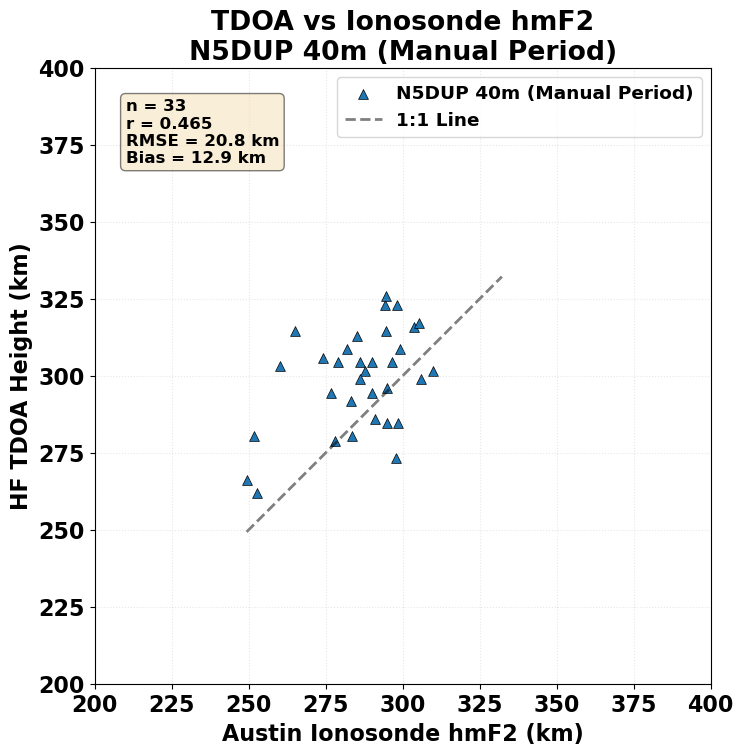

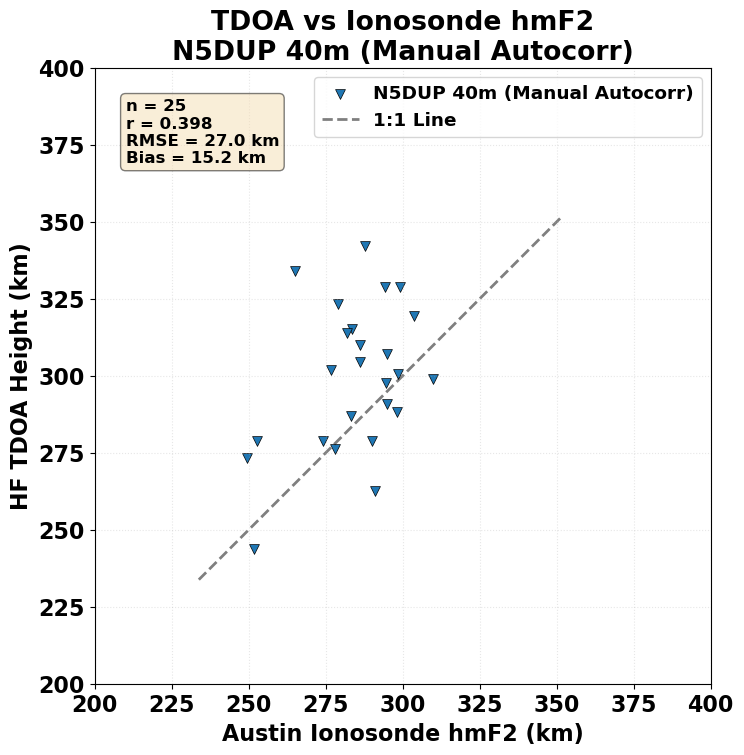

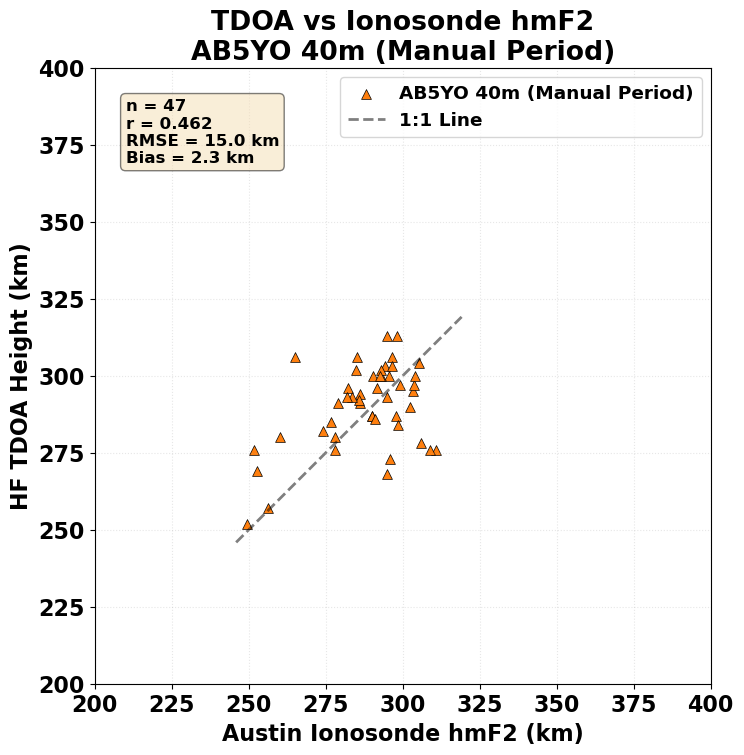

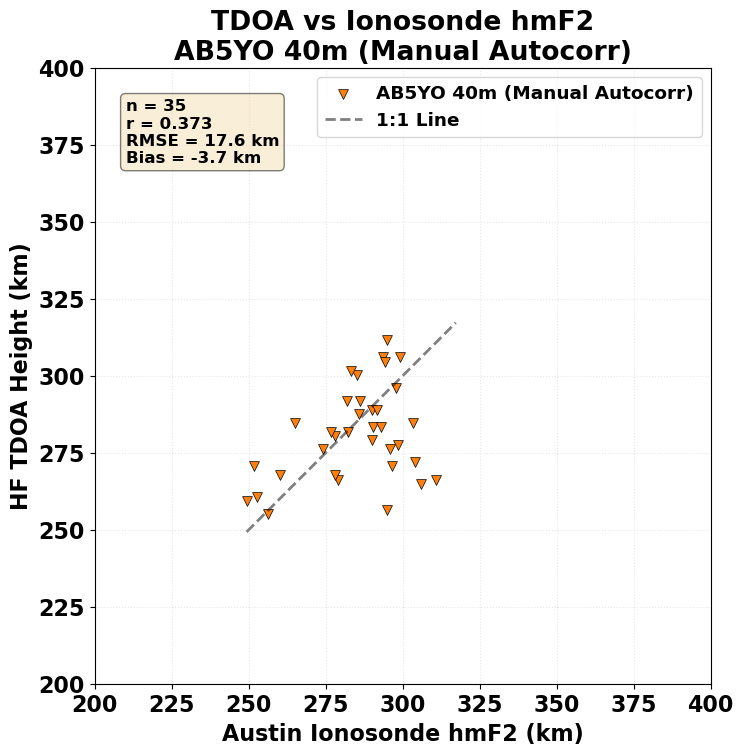

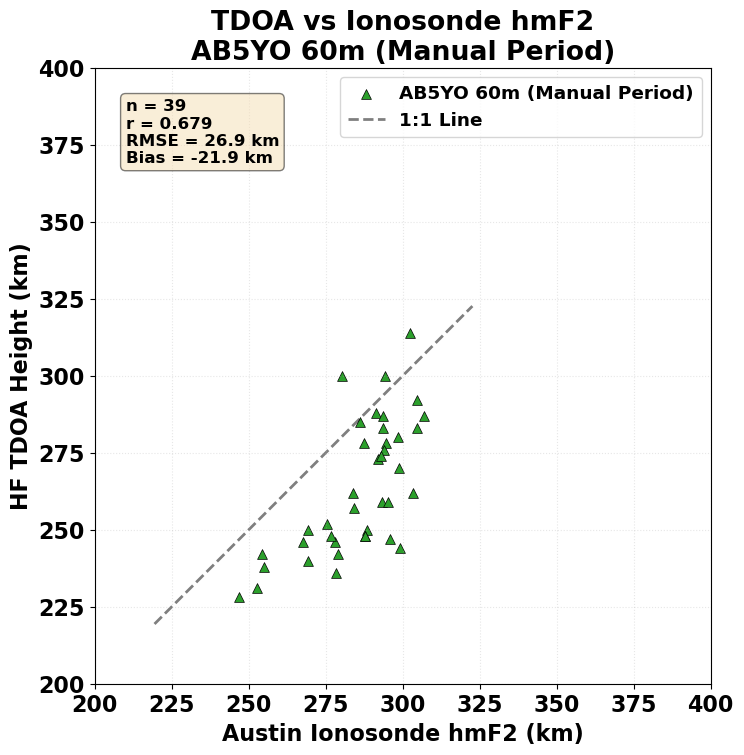

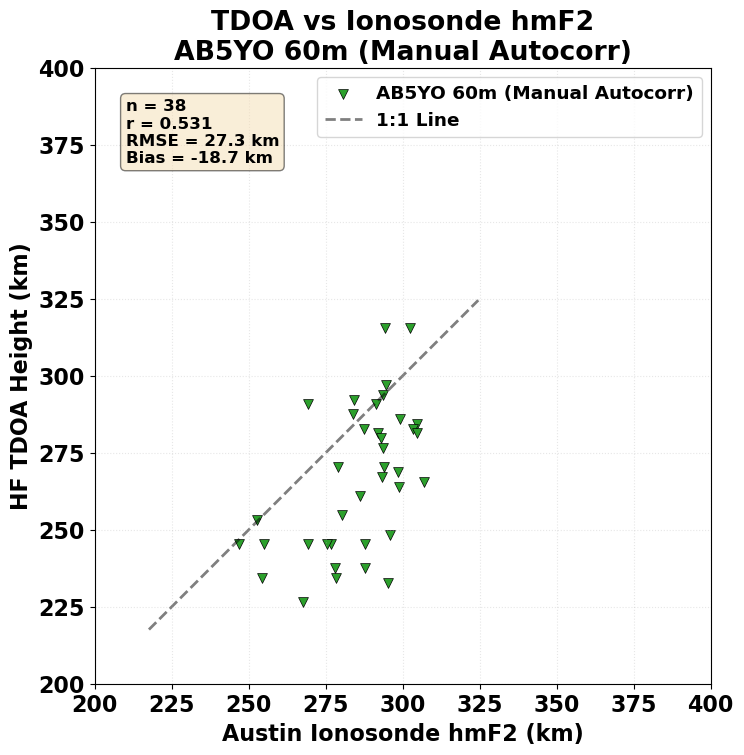

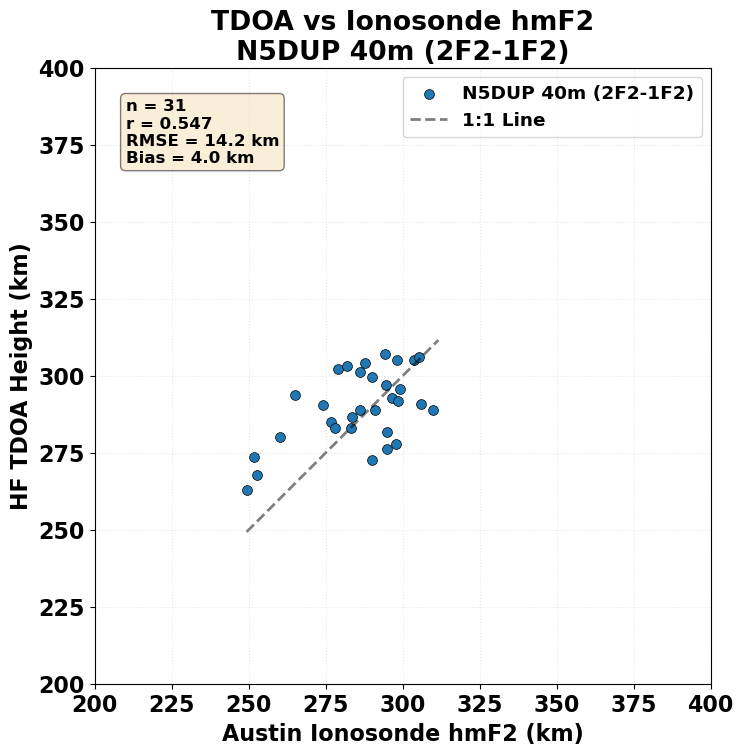

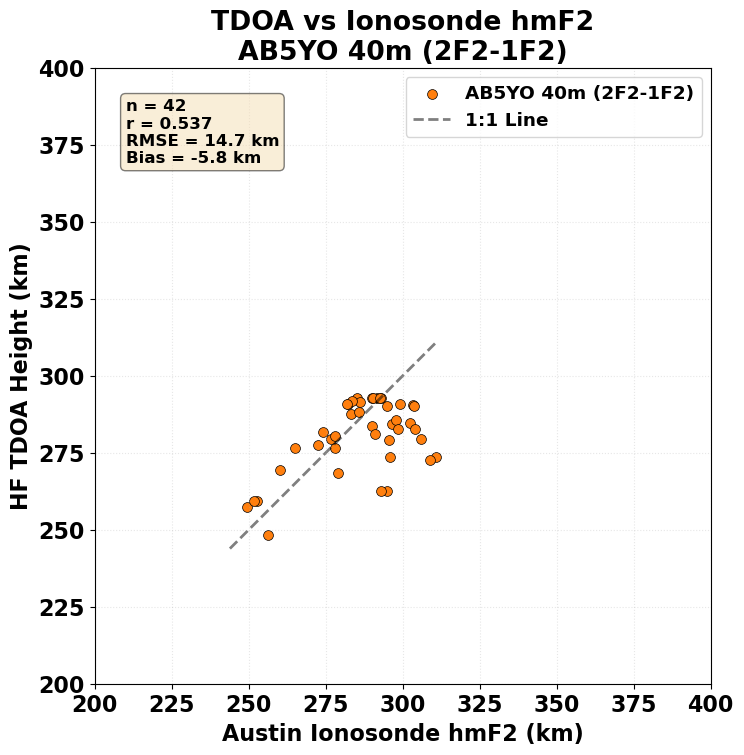

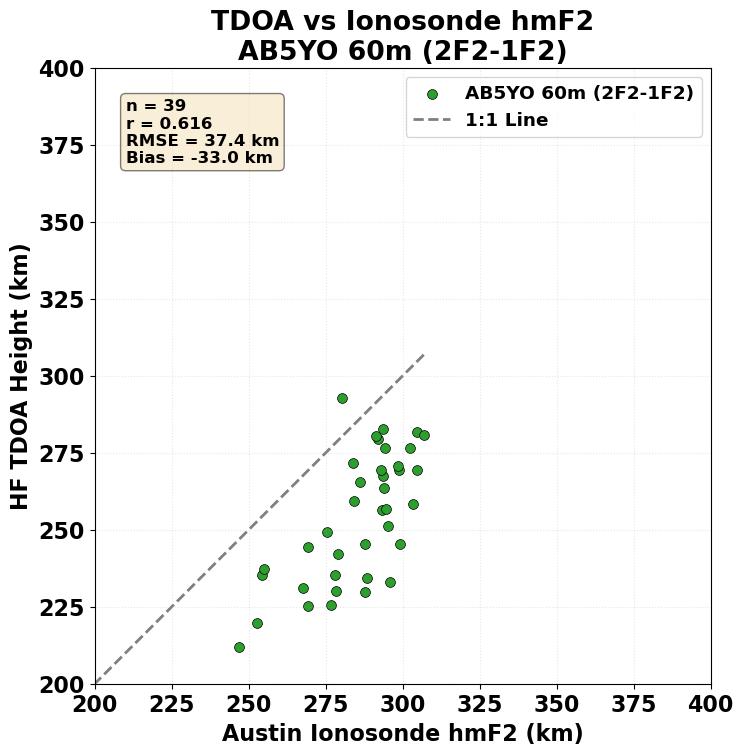

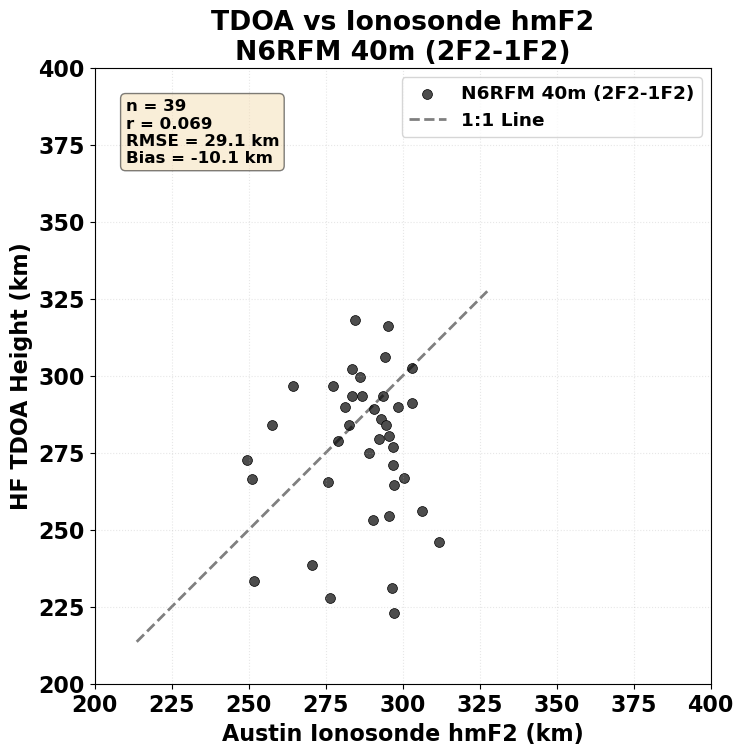

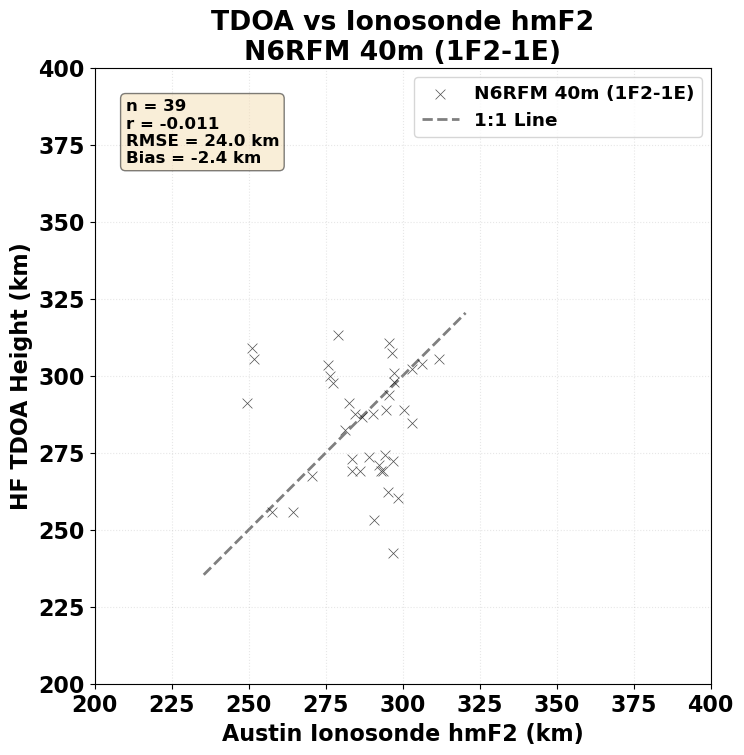

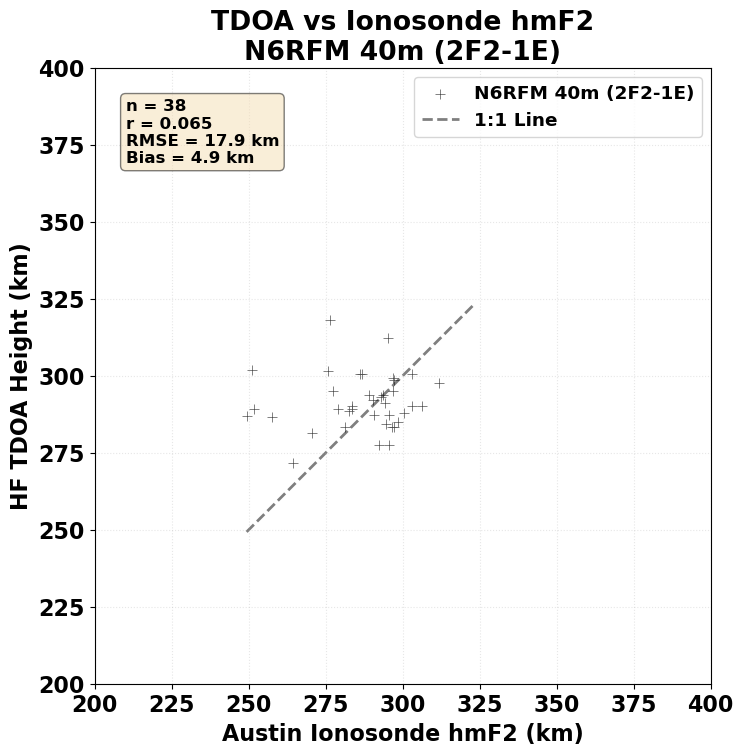

In [4]:
# Create individual scatter plots and save results
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

print("Creating individual scatter plots...\n")

# Manual datasets
print("Manual Analysis:")
manual_results = tdoa.create_scatter_plot_figure(
    manual_datasets,
    ionosonde_df,
    individual_plots=True,
    combined_plot=False,
    output_dir=output_dir
)

# Automated datasets
print("\nAutomated Analysis:")
automated_results = tdoa.create_scatter_plot_figure(
    automated_datasets,
    ionosonde_df,
    individual_plots=True,
    combined_plot=False,
    output_dir=output_dir
)

# Print summary statistics for manual analysis
print("\n" + "="*80)
print("MANUAL ANALYSIS SCATTER PLOT STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE':>10s} {'Bias':>10s}")
print("-"*80)

for label, stats in manual_results.items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse']:9.1f} km {stats['bias']:9.1f} km")
    else:
        print(f"{label:<35s} {'N/A':>6s} {'N/A':>8s} {'N/A':>10s} {'N/A':>10s}")

# Print summary statistics for automated analysis
print("\n" + "="*80)
print("AUTOMATED ANALYSIS SCATTER PLOT STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE':>10s} {'Bias':>10s}")
print("-"*80)

for label, stats in automated_results.items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse']:9.1f} km {stats['bias']:9.1f} km")
    else:
        print(f"{label:<35s} {'N/A':>6s} {'N/A':>8s} {'N/A':>10s} {'N/A':>10s}")

print("="*80)

## Combined Scatter Plot - Manual vs Automated Analysis

Create a 2x2 panel figure comparing manual and automated TDOA analysis methods:

**Layout:**
- **Top row (a-b):** Manual analysis datasets (period and autocorrelation methods)
  - Panel (a): Scatter plot of all manual datasets
  - Panel (b): Statistics table for manual datasets
- **Bottom row (c-d):** Automated analysis datasets (from Figures 11-13)
  - Panel (c): Scatter plot of all automated datasets
  - Panel (d): Statistics table for automated datasets

This layout allows direct comparison between:
- Manual vs automated measurement techniques
- Different receiver locations and propagation modes
- Overall correlation with ionosonde measurements for each method

Creating 2x2 scatter plot figure (manual vs automated)...



/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('0.3') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)
/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('0.3') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)


Saved: fig_14.jpg

Figure 14 saved to: fig_14.jpg

MANUAL ANALYSIS STATISTICS
Dataset                                  n        r     RMSE (%)     Bias (%)
--------------------------------------------------------------------------------
N5DUP 40m (Manual Period)               33    0.465         7.3%         4.5%
N5DUP 40m (Manual Autocorr)             25    0.398         9.5%         5.4%
AB5YO 40m (Manual Period)               47    0.462         5.2%         0.8%
AB5YO 40m (Manual Autocorr)             35    0.373         6.2%        -1.3%
AB5YO 60m (Manual Period)               39    0.679         9.4%        -7.7%
AB5YO 60m (Manual Autocorr)             38    0.531         9.6%        -6.6%

AUTOMATED ANALYSIS STATISTICS
Dataset                                  n        r     RMSE (%)     Bias (%)
--------------------------------------------------------------------------------
N5DUP 40m (2F2-1F2)                     31    0.547         5.0%         1.4%
AB5YO 40m (2F2-1F2)        

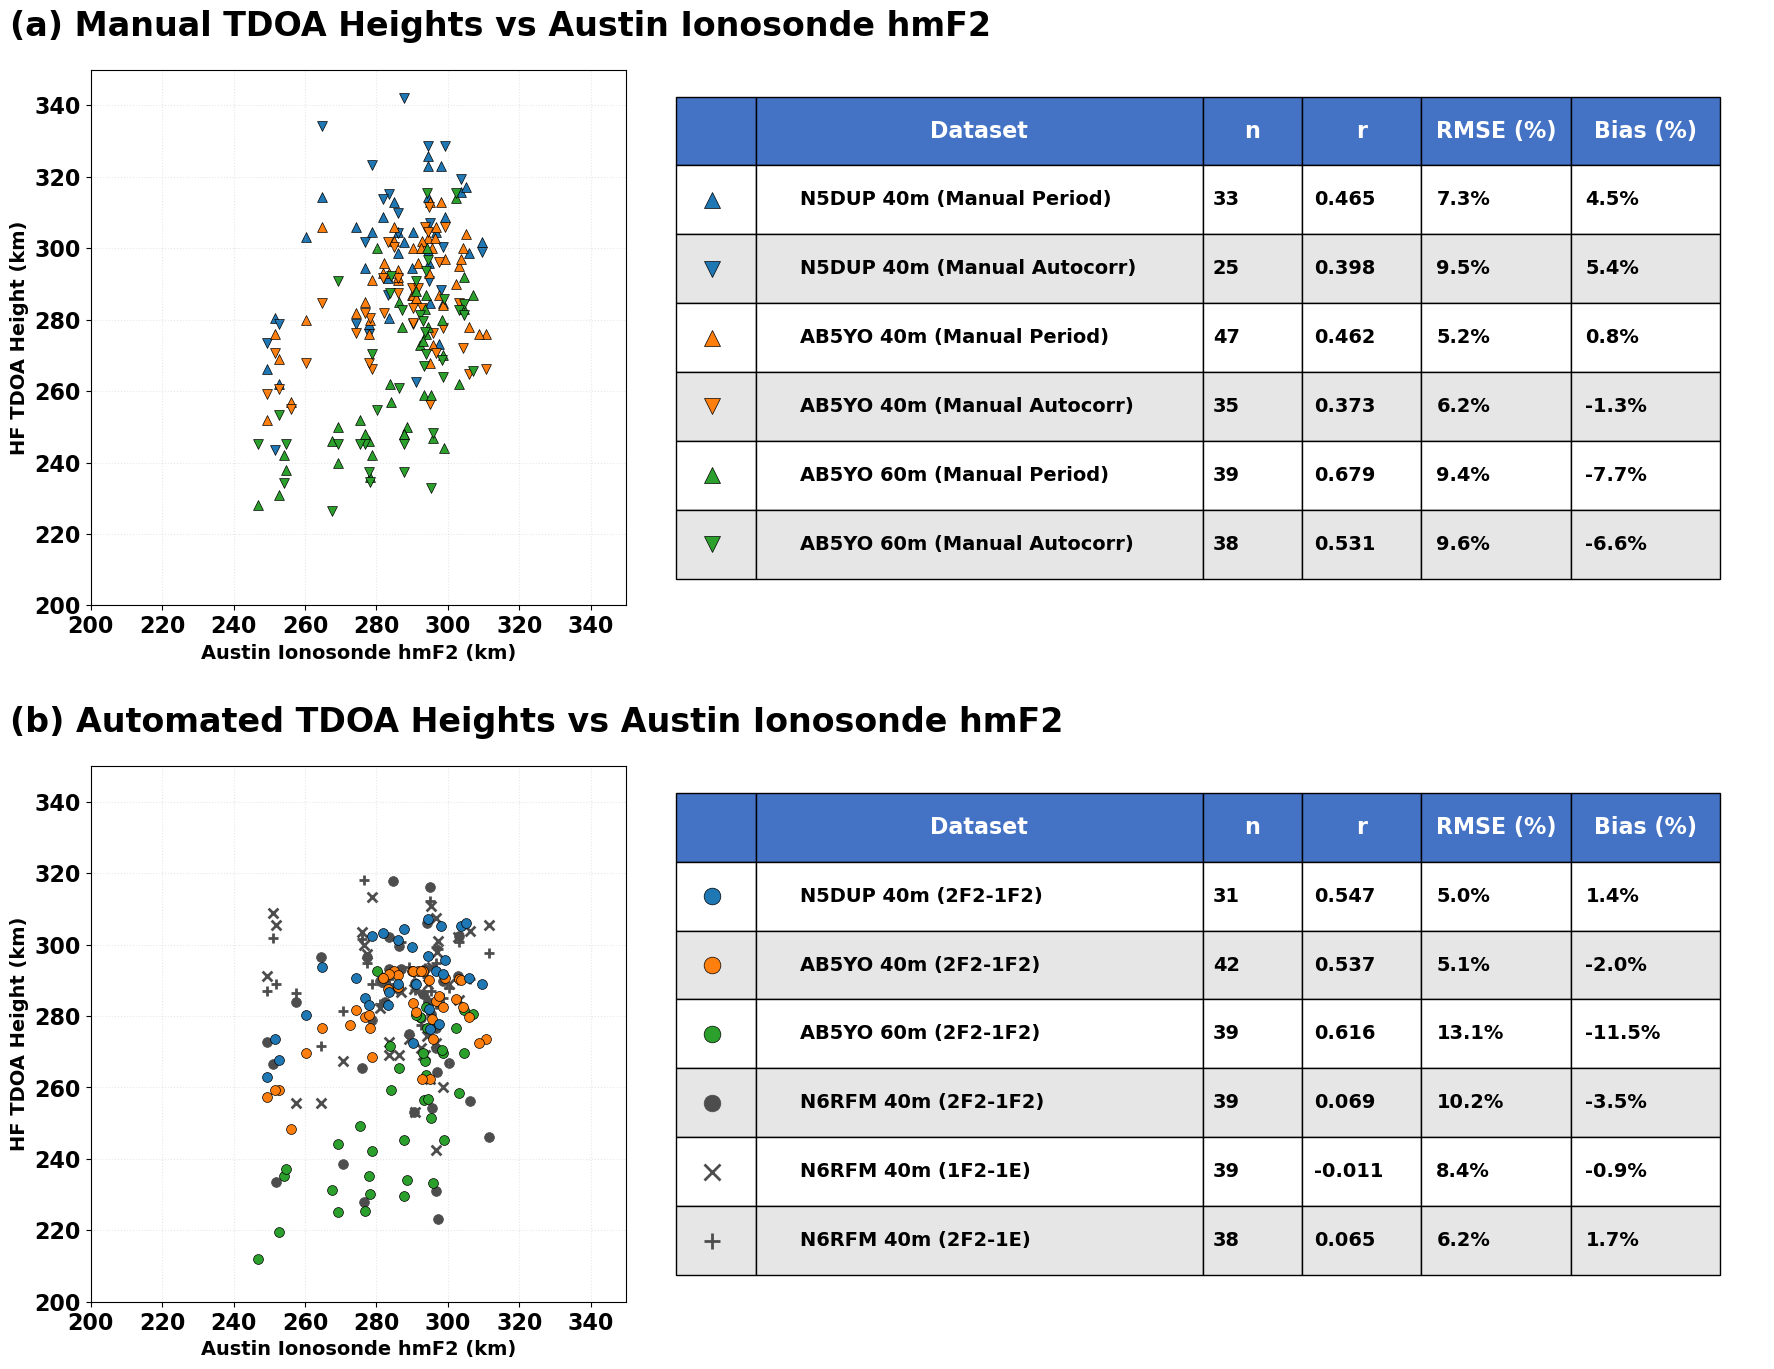

In [5]:
# Create combined scatter plot comparing manual vs automated analysis
print("Creating 2x2 scatter plot figure (manual vs automated)...\n")

results_combined = tdoa.create_manual_vs_automated_scatter_figure(
    manual_datasets,
    automated_datasets,
    ionosonde_df,
    filepath='fig_14.jpg'
)

print("\nFigure 14 saved to: fig_14.jpg")

# Print summary statistics for manual analysis
print("\n" + "="*80)
print("MANUAL ANALYSIS STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE (%)':>12s} {'Bias (%)':>12s}")
print("-"*80)

for label, stats in results_combined['manual'].items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse_percent']:11.1f}% {stats['bias_percent']:11.1f}%")

# Print summary statistics for automated analysis
print("\n" + "="*80)
print("AUTOMATED ANALYSIS STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE (%)':>12s} {'Bias (%)':>12s}")
print("-"*80)

for label, stats in results_combined['automated'].items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse_percent']:11.1f}% {stats['bias_percent']:11.1f}%")

print("="*80)

## Summary

This notebook creates comprehensive scatter plot comparisons between HF TDOA height measurements and Austin Ionosonde hmF2 values, comparing both manual and automated analysis methods.

### Outputs Generated:

1. **Individual Scatter Plots** (`output/scatter_*.jpg`)
   - One plot per dataset vs ionosonde
   - Separate plots for manual and automated datasets
   - Includes correlation statistics (r, RMSE, bias, percent error)

2. **Combined 2x2 Scatter Plot** (`fig_14.jpg`)
   - Top row (a-b): Manual analysis scatter plot and statistics table
   - Bottom row (c-d): Automated analysis scatter plot and statistics table
   - Color-coded by dataset with unique markers
   - Integrated statistics tables with symbols
   - Provides comprehensive comparison view

### Key Findings:

The statistics tables show the correlation (r), root mean square error (RMSE %), and bias (%) for each dataset compared to the ionosonde hmF2 measurements. These metrics allow quantitative assessment of:

**Manual Analysis Methods:**
- Period analysis: Manual measurement of chirp repetition period
- Autocorrelation analysis: Automated detection using autocorrelation

**Automated Analysis Methods:**
- Multiple propagation modes: 2F2-1F2, 1F2-1E, 2F2-1E
- Multiple receiver locations: N5DUP, AB5YO, N6RFM
- Multiple frequency bands: 40m and 60m

**Comparison Metrics:**
- **n**: Number of matched data points with ionosonde measurements
- **r**: Correlation coefficient (closer to 1.0 indicates better linear agreement)
- **RMSE (%)**: Root mean square error as percent of mean ionosonde height
- **Bias (%)**: Systematic offset as percent of mean ionosonde height

The comparison enables evaluation of:
- Agreement between manual and automated TDOA methods
- Performance of different propagation modes
- Consistency across different receiver locations and frequency bands
- Overall accuracy of TDOA-based ionospheric height estimation